In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import joblib

In [2]:
data=pd.read_csv(r"C:\Users\impor\Downloads\churn_prediction\data\telecom_churn.csv")

In [3]:
data.head(5)

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [5]:
data.Churn.value_counts()

Churn
0    2850
1     483
Name: count, dtype: int64

In [6]:
data.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [7]:
#duplicate check?
print(data.duplicated().sum())

0


# Exploratoty Data Analysis

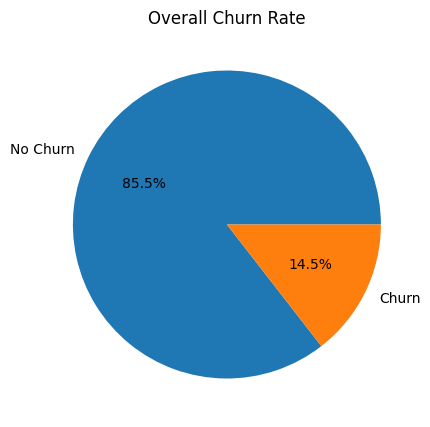

In [8]:
#1. What is the overall churn rate?
#📊 Chart: Pie chart or Bar chart
#💡 Why: First thing any company wants to know
plt.figure(figsize=(5,5))
plt.pie(data.Churn.value_counts(), labels=['No Churn', 'Churn'], autopct='%.1f%%')
plt.title('Overall Churn Rate')
plt.show()

from this graph, the data is filled with so much biasness towards no churn category.

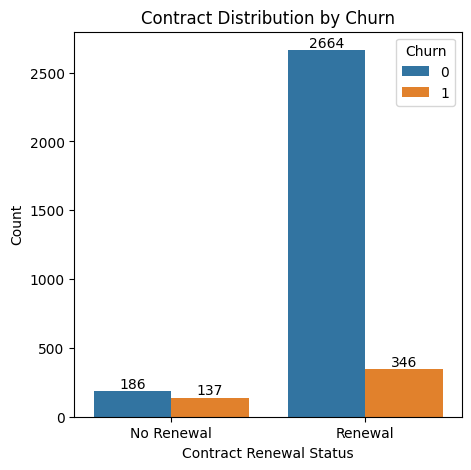

In [9]:
#contractrenewal vs churn
plt.figure(figsize=(5,5))
sns.countplot(data=data, x='ContractRenewal', hue='Churn')
plt.title('Contract Distribution by Churn')
plt.xlabel('Contract Renewal Status')
plt.ylabel('Count')

# Customize x-axis labels for better understanding
plt.xticks(ticks=[0, 1], labels=['No Renewal', 'Renewal'])

# Add count labels on top of the bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.show()

customers who do not renew their contract are highly likely to churn, making contract renewal a critical factor in predicting churn.

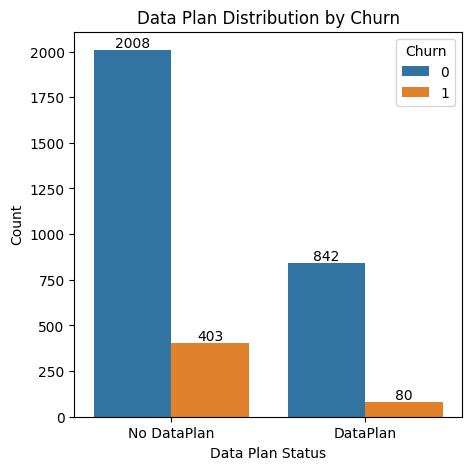

In [10]:
#3. Churn vs Data Plan
#❓ Does having a data plan reduce churn?
#📊 Chart: Bar chart (with hue = churn)
plt.figure(figsize=(5,5))
sns.countplot(data=data, x='DataPlan', hue='Churn')
plt.title('Data Plan Distribution by Churn')
plt.xlabel('Data Plan Status')
plt.ylabel('Count')
# Customize x-axis labels for better understanding
plt.xticks(ticks=[0, 1], labels=['No DataPlan', 'DataPlan'])

# Add count labels on top of the bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='%d')
plt.show()

In [11]:
# Calculate churn rate for customers with and without a data plan
churn_by_dataplan = data.groupby('DataPlan')['Churn'].value_counts(normalize=True).unstack()
display(churn_by_dataplan)

Churn,0,1
DataPlan,,
0,0.832849,0.167151
1,0.913232,0.086768


 Customers who have a data plan are less likely to churn compared to those who do not. This suggests that offering data plans could be a strategy to reduce customer churn

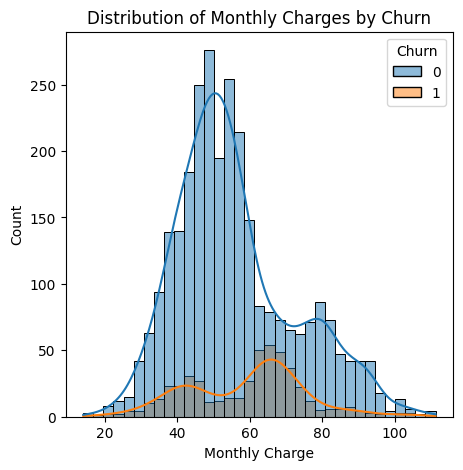

In [12]:
#5. Distribution of Monthly Charges
#📊 Chart: Histogram
#💡 Understand pricing spread
plt.figure(figsize=(5,5))
sns.histplot(data=data, x='MonthlyCharge', hue='Churn', kde=True)
plt.title('Distribution of Monthly Charges by Churn')
plt.xlabel('Monthly Charge')
plt.ylabel('Count')
plt.show()

customers who have lower monthly charges are more likely to churn, while those with higher monthly charges are less likely to churn.,it can also be the critical factor to predict the churn.

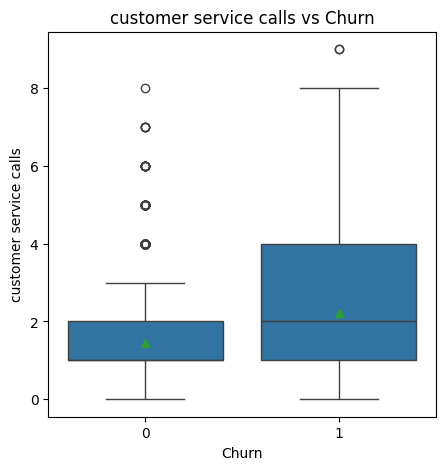

In [13]:
#7. Do customers who call customer service more churn?
#📊 Chart: Box Plot / Violin Plot
#Columns: CustServCalls vs Churn
#💡 VERY strong churn indicator usually
plt.figure(figsize=(5,5))
sns.boxplot(data=data, x='Churn', y='CustServCalls', showmeans=True)
plt.title('customer service calls vs Churn')
plt.xlabel('Churn')
plt.ylabel('customer service calls')
plt.show()

Customers who make more customer service calls are indeed more likely to churn. This makes 'CustServCalls' a strong indicator for predicting churn, suggesting that frequent issues or dissatisfaction could be driving customers away.

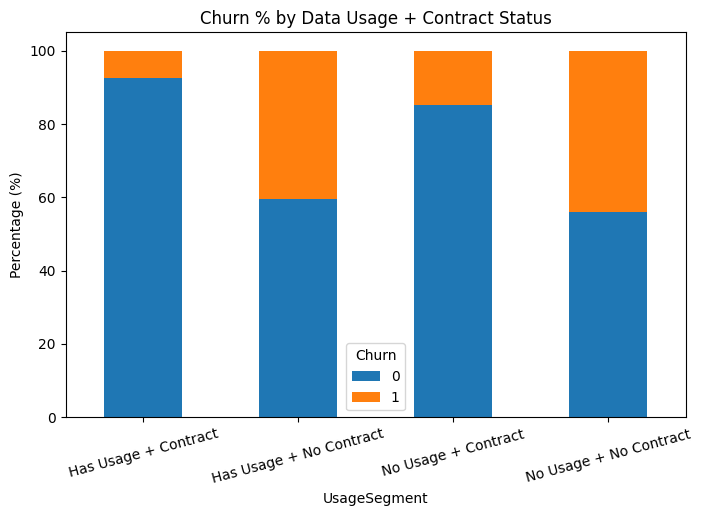

In [14]:
# Relationship between Data Usage  with contract renewal and Churn
data['UsageSegment'] = data.apply(
    lambda row: 'No Usage + No Contract' if row['DataUsage'] == 0 and row['ContractRenewal'] == 0
    else ('No Usage + Contract' if row['DataUsage'] == 0 and row['ContractRenewal'] == 1
    else ('Has Usage + No Contract' if row['DataUsage'] > 0 and row['ContractRenewal'] == 0
    else 'Has Usage + Contract')), axis=1
)

churn_usage = pd.crosstab(
    data['UsageSegment'],
    data['Churn'],
    normalize='index'
) * 100

churn_usage.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Churn % by Data Usage + Contract Status')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=15)
plt.show()

Contract renewal is the dominant retention factor, not data usage. Customers without a contract churn at 40%+ regardless of how much data they use, while contracted customers stay at under 15% churn even with zero data usage. This confirms that locking customers into contracts is a more effective retention strategy than increasing product engagement through data plans.

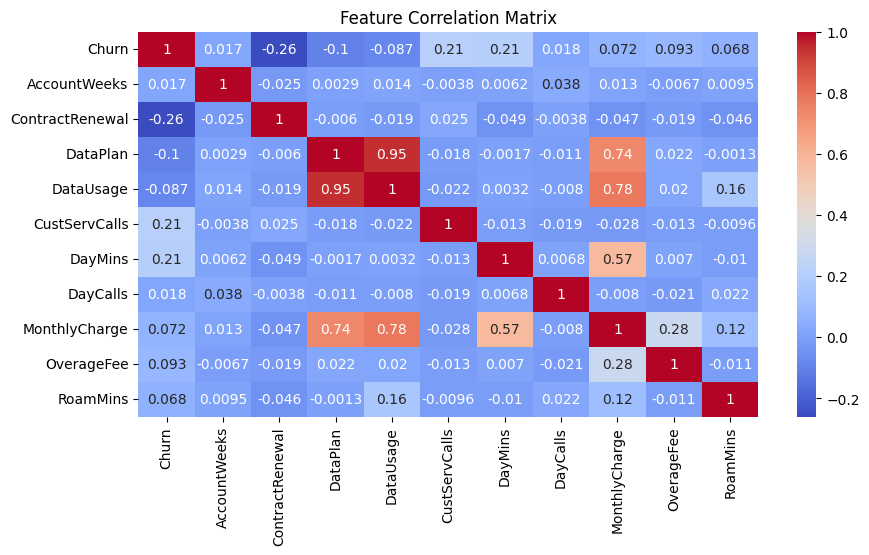

In [15]:
#12. Feature Correlation Matrix
#📊 Chart: Heatmap
#💡 Detect:Strong predictors Multicollinearity
plt.figure(figsize=(10,5))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

Customer churn is primarily influenced by service-related issues and contract status rather than customer tenure. Frequent customer service interactions indicate dissatisfaction and significantly increase churn risk. Additionally, while pricing is driven by usage patterns, its impact on churn is indirect, suggesting that perceived value and service experience play a more critical role than cost alone

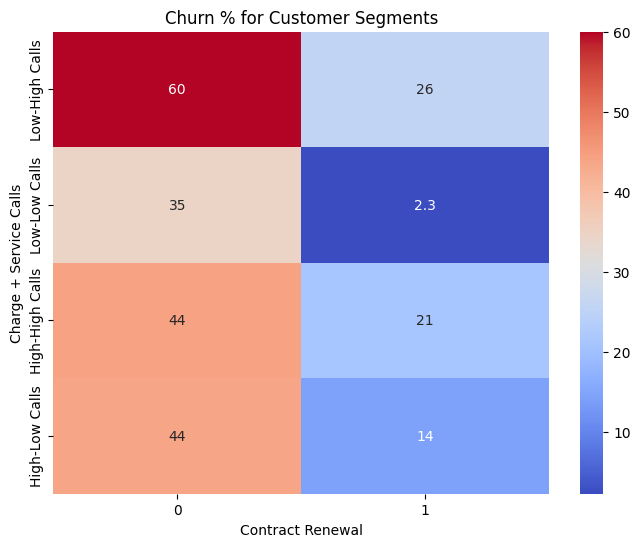

In [16]:
#15. High-Risk Customer Segments
#❓ Which group churns the most?Example: High charge +
# no contract + high service calls
#📊 Chart: Grouped Bar / Pivot Heatmap
data['ChargeCategory'] = pd.qcut(data['MonthlyCharge'], q=2, labels=['Low', 'High'])

data['ServiceCategory'] = data['CustServCalls'].apply(
    lambda x: 'High Calls' if x >= 3 else 'Low Calls'
)
pivot = pd.crosstab(
    [data['ChargeCategory'], data['ServiceCategory'], data['ContractRenewal']],
    data['Churn'],
    normalize='index'
) * 100
plt.figure(figsize=(8,6))
sns.heatmap(pivot[1].unstack(), annot=True, cmap='coolwarm')
plt.title('Churn % for Customer Segments')
plt.ylabel('Charge + Service Calls')
plt.xlabel('Contract Renewal')
plt.show()

Customer churn is primarily driven by service-related issues rather than pricing alone. Customers who frequently contact customer support exhibit significantly higher churn rates across all segments. Additionally, contract renewal plays a crucial role in retention, as it consistently reduces churn across all customer groups. This indicates that improving service quality and encouraging contract renewals are the most effective strategies to reduce churn.

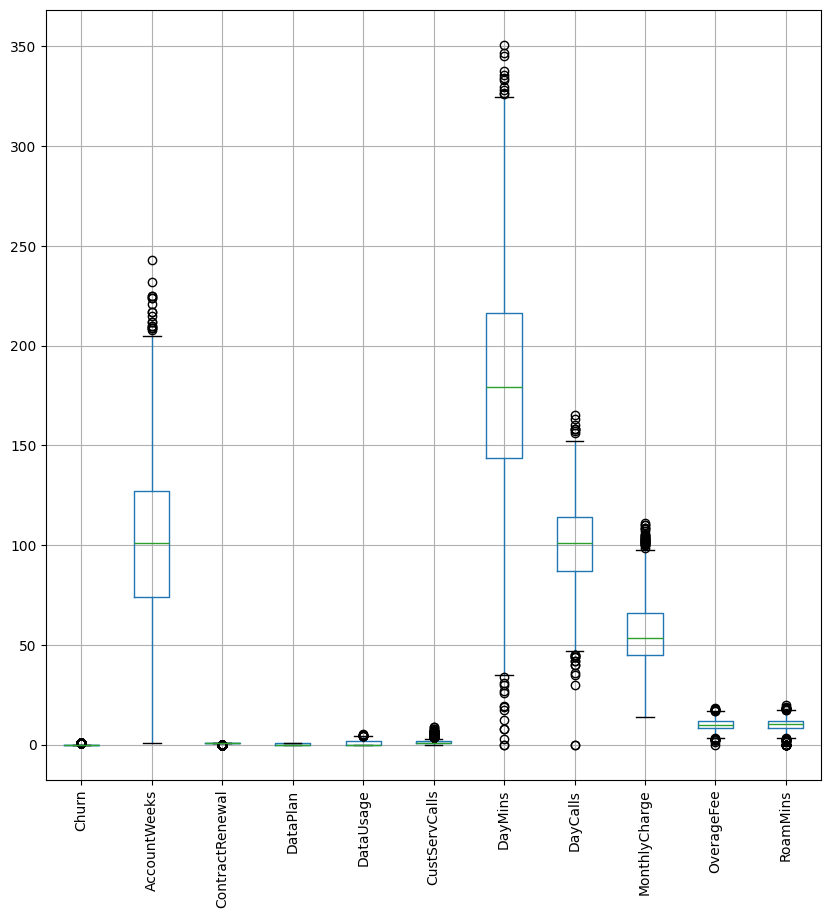

In [17]:
#16. Outlier Detection (Important for ML)
#📊 Chart: Box plots for all numerical features
#💡 Helps in:Cleaning data Improving model performance
plt.figure(figsize=(10,10))
data.boxplot(figsize=(10,5))
plt.xticks(rotation=90)
plt.show()

“Outliers are observed in several numerical features such as DayMins, MonthlyCharge, and CustServCalls. These likely represent genuine high-usage or high-cost customers rather than data errors, and hence are retained for further analysis.”

In [18]:
#19. What is the profile of a churned customer?
#Combine:High MonthlyCharge ,High CustServCalls ,No ContractRenewal
#📊 Chart: Summary table + bar plots
high_charge = data['MonthlyCharge'] > data['MonthlyCharge'].median()
high_calls = data['CustServCalls'] >= 3
no_contract = data['ContractRenewal'] == 0

churn_profile = data[high_charge & high_calls & no_contract]
churn_profile.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,36.000000,36.000000,36.0,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,0.444444,114.472222,0.0,0.527778,1.596111,3.694444,204.516667,104.027778,69.988889,11.019722,10.733333
std,0.503953,30.267839,0.0,0.506309,1.508387,1.141914,44.243175,17.222056,13.648606,2.330097,2.152341
min,0.000000,54.000000,0.0,0.000000,0.000000,3.000000,125.700000,68.000000,53.800000,7.350000,7.200000
25%,0.000000,94.000000,0.0,0.000000,0.000000,3.000000,161.725000,91.000000,58.750000,9.455000,9.025000
50%,0.000000,116.000000,0.0,1.000000,2.270000,3.000000,213.300000,105.000000,68.300000,10.640000,10.500000
75%,1.000000,136.500000,0.0,1.000000,2.917500,4.000000,236.600000,118.250000,78.275000,12.335000,12.000000
max,1.000000,179.000000,0.0,1.000000,3.830000,9.000000,292.900000,135.000000,104.300000,18.190000,16.900000


The typical churned customer in our highest-risk segment is not a disengaged newcomer — they are a 2-year tenure, active user averaging 204 daily minutes who made nearly 4 customer service calls without getting their issues resolved. This segment churns at 44%, three times the overall rate of ~15%. The business implication is serious: the company is losing experienced, high-usage customers due to service failure, not lack of product fit. Retaining this segment requires resolving service complaints faster, not acquisition or engagement campaigns.

Profile Churn Rate: 44.44444444444444
Overall Churn Rate: 14.491449144914492


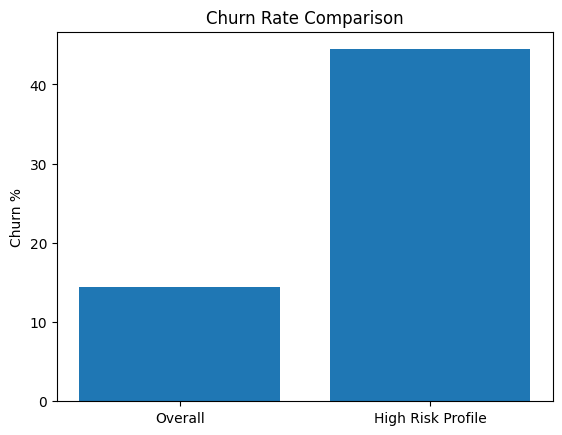

In [19]:
profile_churn_rate = churn_profile['Churn'].mean() * 100
overall_churn_rate = data['Churn'].mean() * 100

print("Profile Churn Rate:", profile_churn_rate)
print("Overall Churn Rate:", overall_churn_rate)
labels = ['Overall', 'High Risk Profile']
values = [overall_churn_rate, profile_churn_rate]

plt.bar(labels, values)
plt.title('Churn Rate Comparison')
plt.ylabel('Churn %')
plt.show()

Customers who churn usually do not have a contract, pay medium to high monthly charges, and contact customer service frequently. These customers use the service regularly, but their repeated complaints show they are not satisfied. Also, they are not necessarily new customers, which means churn is mainly caused by poor service experience and lack of contract commitment, rather than how long the customer has been using the service or how much data they use.

Churn                             0          1
TenureCategory HighCalls                      
New            High       84.615385  15.384615
               Low        88.461538  11.538462
Old            High       73.645681  26.354319
               Low        88.588008  11.411992


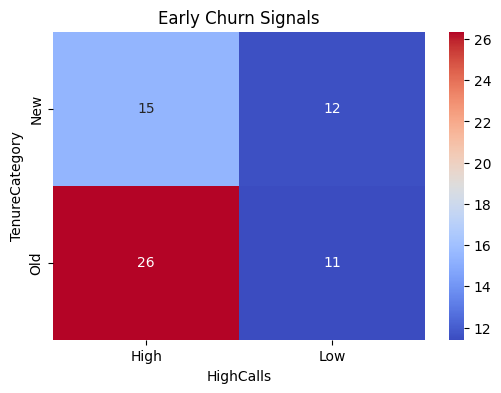

In [20]:
#20. Can we identify early churn signals?
#Look at: Low AccountWeeks, High complaints early
#📊 Chart: Trend / grouped analysis
data['TenureCategory'] = data['AccountWeeks'].apply(
    lambda x: 'New' if x < 20 else 'Old'
)
data['HighCalls'] = data['CustServCalls'].apply(
    lambda x: 'High' if x >= 3 else 'Low'
)
early_churn = pd.crosstab(
    [data['TenureCategory'], data['HighCalls']],
    data['Churn'],
    normalize='index'
) * 100
print(early_churn)
plt.figure(figsize=(6,4))
sns.heatmap(early_churn[1].unstack(), annot=True, cmap='coolwarm')
plt.title('Early Churn Signals')
plt.show()

 the data shows that long-tenure customers making frequent service calls carry the highest churn risk at 26.4% — more than double the baseline of ~11.4%. New customers with high calls churn at only 15.4%, likely because early calls reflect onboarding queries rather than dissatisfaction. This means churn prevention efforts should focus not on new customer onboarding, but on detecting when established customers begin escalating their service interactions — that is the real early warning signal

In [21]:
#1. Contract Renewal vs Churn
#Hypothesis:
#H0: Contract renewal has no effect on churn
#H1: Contract renewal affects churn :
#👉 Chi-Square Test
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data['ContractRenewal'], data['Churn'])
chi2, p, dof, expected  = chi2_contingency(contingency_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

Chi-Square Statistic: 222.5657566499376
P-value: 2.4931077033159556e-50


Contract renewal plays a critical role in customer retention. Customers without an active contract are at a much higher risk of leaving, making contract-based engagement strategies highly effective in reducing churn.

In [22]:
#Customer Service Calls vs Churn 💡 Why?
#Hypothesis: H0: No difference in service calls between churn &
# non-churn H1: Churned customers make more service calls 📊 Test:
#👉 T-Test
from scipy.stats import ttest_ind
churn_calls = data[data['Churn'] == 1]['CustServCalls']
non_churn_calls = data[data['Churn'] == 0]['CustServCalls']
t_statistic, p_value = ttest_ind(churn_calls, non_churn_calls)
print("T-Statistic:", t_statistic)
print("P-value:", p_value)

T-Statistic: 12.319375496769158
P-value: 3.900360240189117e-34


Frequent customer service interactions indicate dissatisfaction, and customers who repeatedly face issues are much more likely to leave the service.

In [23]:
#Monthly Charge vs Churn 💡 Why?
#To validate cost impact
#Hypothesis: H0: Monthly charges
#are same for both groups H1: Monthly charges differ 📊 Test:
#👉 T-Test
from scipy.stats import ttest_ind
churn_monthly = data[data['Churn'] == 1]['MonthlyCharge']
non_churn_monthly = data[data['Churn'] == 0]['MonthlyCharge']
t_statistic, p_value = ttest_ind(churn_monthly, non_churn_monthly)
print("T-Statistic:", t_statistic)
print("P-value:", p_value)

T-Statistic: 4.1844697209089174
P-value: 2.9321518183981925e-05


The t-test results indicate a statistically significant difference in monthly charges between churned and non-churned customers (p < 0.05). This suggests that pricing plays a role in churn behavior. However, compared to other factors such as customer service interactions, its impact is relatively moderate.

In [24]:
#4. Combined Effect (Calls + Contract) vs Churn
#This matches your best insight: combination effect
#Hypothesis: H0: No relationship between combined factors and churn H1: Combined factors significantly affect churn 📊 Test:
#👉 Chi-Square (on grouped categories)
# Step 1: Create category for service calls
data['ServiceCategory'] = data['CustServCalls'].apply(
    lambda x: 'High' if x >= 3 else 'Low'
)
# Step 2: Create contingency table
combined_table = pd.crosstab(
    [data['ContractRenewal'], data['ServiceCategory']],
    data['Churn']
)
# Step 3: Chi-Square Test
chi2, p, dof, expected = chi2_contingency(combined_table)
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

Chi-Square Statistic: 323.1437905338512
P-value: 9.731800715850224e-70


The Chi-Square test results show an extremely significant relationship (p ≈ 9.73 × 10⁻⁷⁰) between the combined factors of contract renewal and customer service interactions and churn. This indicates that customers who do not renew their contracts and frequently contact customer service are at the highest risk of churning.

In [25]:
#correlation with other numerical columns relation
corr_matrix = data.corr(numeric_only=True)
print(corr_matrix['Churn'])

Churn              1.000000
AccountWeeks       0.016541
ContractRenewal   -0.259852
DataPlan          -0.102148
DataUsage         -0.087195
CustServCalls      0.208750
DayMins            0.205151
DayCalls           0.018459
MonthlyCharge      0.072313
OverageFee         0.092812
RoamMins           0.068239
Name: Churn, dtype: float64


#buiding a model

In [26]:
data

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins,UsageSegment,ChargeCategory,ServiceCategory,TenureCategory,HighCalls
0,0,128,1,1,2.70,1,265.1,110,89.0,9.87,10.0,Has Usage + Contract,High,Low,Old,Low
1,0,107,1,1,3.70,1,161.6,123,82.0,9.78,13.7,Has Usage + Contract,High,Low,Old,Low
2,0,137,1,0,0.00,0,243.4,114,52.0,6.06,12.2,No Usage + Contract,Low,Low,Old,Low
3,0,84,0,0,0.00,2,299.4,71,57.0,3.10,6.6,No Usage + No Contract,High,Low,Old,Low
4,0,75,0,0,0.00,3,166.7,113,41.0,7.42,10.1,No Usage + No Contract,Low,High,Old,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3328,0,192,1,1,2.67,2,156.2,77,71.7,10.78,9.9,Has Usage + Contract,High,Low,Old,Low
3329,0,68,1,0,0.34,3,231.1,57,56.4,7.67,9.6,Has Usage + Contract,High,High,Old,High
3330,0,28,1,0,0.00,2,180.8,109,56.0,14.44,14.1,No Usage + Contract,High,Low,Old,Low
3331,0,184,0,0,0.00,2,213.8,105,50.0,7.98,5.0,No Usage + No Contract,Low,Low,Old,Low


In [27]:
data=data.drop(columns=['UsageSegment', 'ChargeCategory', 'ServiceCategory', 'TenureCategory', 'HighCalls'])

In [28]:
X=data.drop(columns=['Churn'])
y=data['Churn']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
#imbalanced data to balanced data
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [31]:
#Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

In [32]:
#logistic regression
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train_resampled)
y_pred_log = log_model.predict(X_test_scaled)

In [33]:
#Decision tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=5)
dt_model.fit(X_train_scaled, y_train_resampled)
y_pred_dt = dt_model.predict(X_test_scaled)

In [34]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(max_depth=5)
rf_model.fit(X_train_scaled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_scaled)

In [35]:

#Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(max_depth=5)
gb_model.fit(X_train_scaled, y_train_resampled)
y_pred_gb = gb_model.predict(X_test_scaled)

In [36]:
#XGBoost
from xgboost.sklearn import XGBClassifier
xgb_model = XGBClassifier(max_depth=5)
xgb_model.fit(X_train_scaled, y_train_resampled)
y_pred_xgb= xgb_model.predict(X_test_scaled)

In [37]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

models = {
    'Logistic Regression': (log_model, y_pred_log),
    'Decision Tree':       (dt_model,  y_pred_dt),
    'Random Forest':       (rf_model,  y_pred_rf),
    'Gradient Boosting':   (gb_model,  y_pred_gb),
    'XGBoost':             (xgb_model, y_pred_xgb)
}

results = []
for name, (model, y_pred) in models.items():
    report = classification_report(y_test, y_pred, output_dict=True)
    y_prob = model.predict_proba(X_test_scaled)[:, 1] #[: , 1] to get probabilities for the positive class
    results.append({
        'Model':     name,
        'Precision': report['1']['precision'],
        'Recall':    report['1']['recall'],
        'F1-Score':  report['1']['f1-score'],
        'AUC-ROC':   round(roc_auc_score(y_test, y_prob), 2)
    })

comparison_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
display(comparison_df)

,Model,Precision,Recall,F1-Score,AUC-ROC
2,Random Forest,0.588652,0.821782,0.685950,0.90
1,Decision Tree,0.573427,0.811881,0.672131,0.85
0,Logistic Regression,0.423077,0.762376,0.544170,0.83
3,Gradient Boosting,0.614754,0.742574,0.672646,0.89
4,XGBoost,0.620690,0.712871,0.663594,0.88


#1. Precision=>
Out of all customers predicted as churn, how many actually churned?

#2. Recall=>
Out of all actual churn customers, how many did we catch?

#3. F1-Score=>
“Overall performance considering both precision and recall”

#hyparperameter tuning

In [38]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 6, 8, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='recall',   # VERY IMPORTANT (focus on churn)
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train_resampled)
best_params = grid_search.best_params_
print("Best CV Recall Score:", round(grid_search.best_score_, 4))

Best CV Recall Score: 0.9321


In [39]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

In [41]:
print("Best Random Forest\n", classification_report(y_test, y_pred_best))

Best Random Forest
               precision    recall  f1-score   support

           0       0.96      0.92      0.94       566
           1       0.64      0.76      0.70       101

    accuracy                           0.90       667
   macro avg       0.80      0.84      0.82       667
weighted avg       0.91      0.90      0.90       667



C:\Users\impor\AppData\Local\Temp\ipykernel_32076\3673797133.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=thresholds, y=recalls[:-1], palette='rainbow')


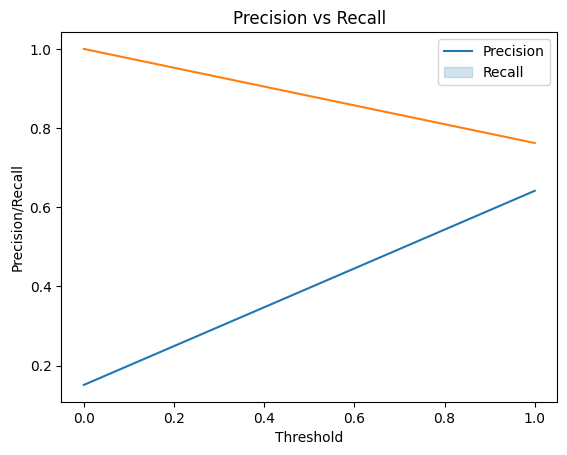

In [42]:
#Thresold tuning
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, y_pred_best)
sns.lineplot(x=thresholds, y=precisions[:-1]   )
sns.lineplot(x=thresholds, y=recalls[:-1], palette='rainbow')
plt.title('Precision vs Recall')
plt.xlabel('Threshold')
plt.ylabel('Precision/Recall')
plt.legend(['Precision', 'Recall'])
plt.show()

The threshold tuning graph shows a clear trade-off between precision and recall. Lower thresholds increase recall, allowing the model to identify more churn customers, while higher thresholds improve precision but miss potential churn cases. Since the business goal is to minimize customer loss, a lower threshold was selected to prioritize recall.

As you change the threshold:

Precision increases (model becomes more strict)
Recall decreases (model misses more churn customers)

In [43]:
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.4).astype(int)
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred = (y_prob >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       566
           1       0.54      0.85      0.66       101

    accuracy                           0.87       667
   macro avg       0.76      0.86      0.79       667
weighted avg       0.91      0.87      0.88       667


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       566
           1       0.60      0.81      0.69       101

    accuracy                           0.89       667
   macro avg       0.78      0.86      0.81       667
weighted avg       0.91      0.89      0.90       667


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       566
           1       0.64      0.76      0.70       101

    accuracy                           0.90       667
   macro avg       0.80      0.84      0.82       667
weighted avg       0.91   

A threshold of 0.4 provides the best trade-off between identifying churn customers and minimizing false positives, making it the most suitable choice for business decision-making.

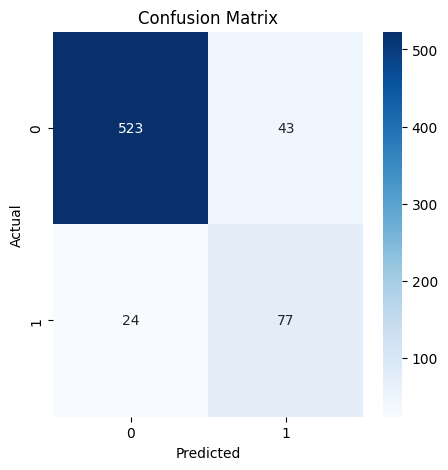

In [44]:
#confusionmatrix graph
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The model achieves a good balance by capturing most churn customers while maintaining a reasonable number of false positives. The false positives can be leveraged as an opportunity to strengthen customer relationships, making the model practically useful for business decision-making.

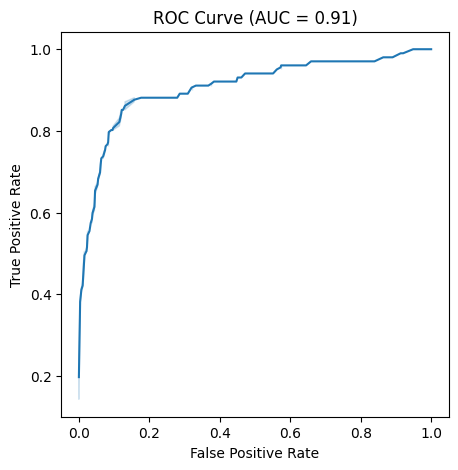

In [45]:
#roc curve
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,5))
sns.lineplot(x=fpr, y=tpr)
plt.title(f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

The model is highly effective in distinguishing between customers who are likely to churn and those who are not, making it reliable for proactive retention strategies.

In [46]:
#Feature Importance
import matplotlib.pyplot as plt
import seaborn as sns
importance = best_rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

           Feature  Importance
1  ContractRenewal    0.194889
7    MonthlyCharge    0.161201
5          DayMins    0.152805
4    CustServCalls    0.125339
8       OverageFee    0.070220
3        DataUsage    0.068018
9         RoamMins    0.061810
0     AccountWeeks    0.060979
6         DayCalls    0.058721
2         DataPlan    0.046017


Feature importance analysis revealed that contract renewal, monthly charges, and customer service interactions are the most significant drivers of churn, indicating that both pricing strategy and customer experience play critical roles in retention.”

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()
# Input + Hidden layers
model.add(Dense(32, activation='relu', input_dim=X_train_resampled.shape[1]))
model.add(Dense(16, activation='relu'))
# Output layer
model.add(Dense(1, activation='sigmoid'))

In [48]:
import tensorflow as tf

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.Recall()]
)
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

model.fit(
    X_train_scaled, y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
115/115 [==============================] - 1s 4ms/step - loss: 0.5904 - recall: 0.3453 - val_loss: 0.6735 - val_recall: 0.6083
Epoch 2/50
115/115 [==============================] - 0s 2ms/step - loss: 0.4619 - recall: 0.6606 - val_loss: 0.5446 - val_recall: 0.7856
Epoch 3/50
115/115 [==============================] - 0s 2ms/step - loss: 0.4067 - recall: 0.7547 - val_loss: 0.4695 - val_recall: 0.8479
Epoch 4/50
115/115 [==============================] - 0s 2ms/step - loss: 0.3744 - recall: 0.8109 - val_loss: 0.4398 - val_recall: 0.8676
Epoch 5/50
115/115 [==============================] - 0s 2ms/step - loss: 0.3551 - recall: 0.8285 - val_loss: 0.4256 - val_recall: 0.8720
Epoch 6/50
115/115 [==============================] - 0s 2ms/step - loss: 0.3394 - recall: 0.8416 - val_loss: 0.4267 - val_recall: 0.8643
Epoch 7/50
115/115 [==============================] - 0s 2ms/step - loss: 0.3289 - recall: 0.8380 - val_loss: 0.4101 - val_recall: 0.8742
Epoch 8/50
115/115 [==============

In [49]:
y_prob_ann = model.predict(X_test_scaled)

y_pred_ann = (y_prob_ann >= 0.5).astype(int)  # use your best threshold

21/21 [==============================] - 0s 1ms/step


In [50]:
from sklearn.metrics import classification_report

print("ANN Model\n")
print(classification_report(y_test, y_pred_ann))

ANN Model

              precision    recall  f1-score   support

           0       0.96      0.90      0.93       566
           1       0.59      0.81      0.68       101

    accuracy                           0.89       667
   macro avg       0.78      0.86      0.81       667
weighted avg       0.91      0.89      0.89       667



The ANN model performs well in identifying churn customers with high recall, but it produces more false positives compared to Random Forest, making it slightly less efficient for business decision-making.

The ANN model performs well in identifying churn customers with high recall, but it produces more false positives compared to Random Forest, making it slightly less efficient for business decision-making.

ReLU is an activation function that outputs zero for negative values and keeps positive values unchanged, helping neural networks learn complex patterns efficiently

“For churn prediction, I implemented a simple feedforward Artificial Neural Network. The model consists of two hidden layers with 32 and 16 neurons, using ReLU activation to capture non-linear relationships in the data. The output layer uses a sigmoid activation function to generate a probability score representing the likelihood of a customer churning.

Since this is a binary classification problem, I applied a custom threshold of 0.4 to convert probabilities into final predictions, prioritizing recall to identify more at-risk customers.

While the ANN performed well, Random Forest achieved better precision and overall balance, so it was selected as the final model.”

In [51]:
#download the best model
#import joblib
#joblib.dump(best_rf, 'best_rf_model.pkl')
from sklearn.pipeline import Pipeline
import joblib

# Build pipeline AFTER GridSearchCV gives you best params
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(**grid_search.best_params_, random_state=42))
])

# Fit on ORIGINAL (not pre-scaled) resampled data
pipeline.fit(X_train_resampled, y_train_resampled)

# Save the entire pipeline
joblib.dump(pipeline, 'churn_pipeline.pkl')

['churn_pipeline.pkl']

Buissness Interpretation=>>


**Opening (Set the Context First)**

"This project simulates a real client engagement. Imagine a telecom company is losing customers and doesn't know why or who to target. They come to us, we analyze their data and build a solution."


**The Business Problem**

"The company has a 14.5% churn rate. That sounds small but in telecom, acquiring a new customer costs 5x more than retaining an existing one. So even a 1% reduction in churn saves significant revenue."


**What the Data Told Us (3 key findings)**
Finding 1 — Contract renewal is everything

"Customers without a contract churn at 40%+. Customers with a contract churn at under 15% — regardless of any other factor. So the single most effective retention lever is getting customers to sign or renew a contract."

**Finding 2 — Service failure, not price, drives churn**

"Our highest risk segment — high charges, high service calls, no contract — churns at 44%. But here's the important part: these are 2-year tenure customers making 204 minutes of calls daily. They are not disengaged. They tried to fix their problems through 3-4 service calls and gave up. The company is losing its best customers due to service failure, not pricing."

**Finding 3 — You can predict churn before it happens**

"When an established customer starts making repeated service calls, churn probability doubles. That's an early warning signal the company can act on in real time."


**What We Built and Why It Matters**

"We built a Random Forest model optimized for recall — meaning we prioritize catching as many churners as possible, even at the cost of some false positives. The reason is business logic: it's cheaper to offer a retention discount to a customer who wasn't going to leave than to lose a customer you never flagged."


"The Streamlit app lets the retention team score any customer in real time. Before a service call, they enter the customer profile, get a churn probability, and the app tells them exactly what action to take — whether to offer a contract incentive, escalate the complaint, or do nothing."


**The Business Recommendations (What the Client Should Do)**

"Based on our analysis, we gave the client three specific recommendations:

Launch contract renewal campaigns 60-90 days before expiry, targeting medium and high risk customers identified by the model
Flag any customer making 3+ service calls in 30 days for proactive outreach — don't wait for them to cancel
For the highest risk segment — high charge, no contract, repeated calls — assign a dedicated retention agent, not just automated outreach"



**How to Close the Answer**

"The model itself is not the deliverable. The deliverable is the retention strategy it enables. A 5% improvement in retention for a mid-size telecom company with 100,000 customers at $65/month average charge is $3.9 million in preserved annual revenue. That's the business case."


One Thing to Remember
**If they ask "why Random Forest over XGBoost or the ANN?" — say:**

"Random Forest gave the best balance of recall and precision after threshold tuning. XGBoost had similar AUC but lower recall on the minority class. The ANN had high recall but too many false positives, which means the retention team would waste resources on customers who weren't going to leave anyway."